# California Housing

## Importing The Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Importing the dataset

#### Training dataset

In [2]:
training_dataset = pd.read_csv('sample_data/california_housing_train.csv')
x_train = training_dataset.iloc[:, :-1].values
y_train = training_dataset.iloc[:, -1].values

#### Testing dataset

In [3]:
testing_dataset = pd.read_csv('sample_data/california_housing_test.csv')
x_test = testing_dataset.iloc[:, :-1].values
y_test = testing_dataset.iloc[:, -1].values

### EDA

<Axes: >

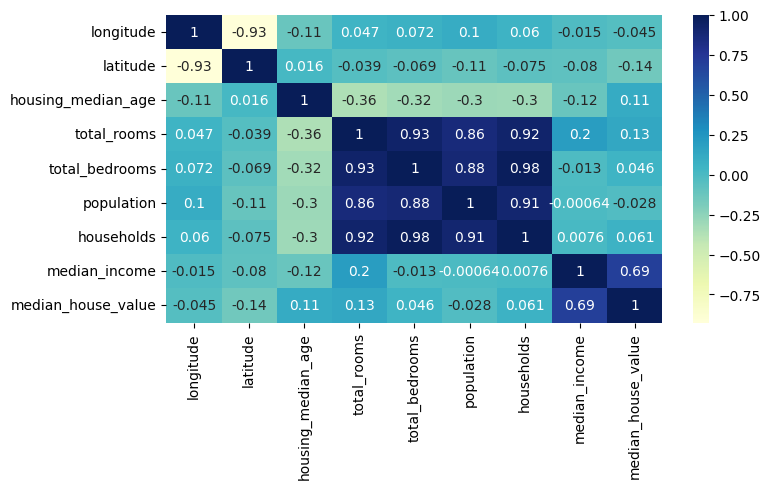

In [4]:
plt.figure(figsize = (8,4))
sns.heatmap(training_dataset.corr(), annot = True, cmap = "YlGnBu")

### Random Forest Model

In [5]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(random_state = 0)

In [6]:
reg_parameters = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1,2,4],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 0.3, 0.5],
}

In [7]:
from sklearn.model_selection import RandomizedSearchCV
cv_reg = RandomizedSearchCV(regressor, reg_parameters, cv = 5, verbose= True,
                            random_state=0, scoring = 'neg_mean_squared_error',
                            n_jobs=-1 ,n_iter= 20)
cv_reg.fit(x_train,y_train)
print("Best parameters: ",cv_reg.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters:  {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': None}


#### Cross Validation

In [8]:
from sklearn.model_selection import cross_val_score
best_rf = cv_reg.best_estimator_
cv_mse = cross_val_score(best_rf, x_train, y_train,
                         cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
cv_rmse = np.sqrt(-cv_mse)
print("RF CV RMSE:", cv_rmse.mean())

RF CV RMSE: 76525.54272531012


#### Evaluation for Random Forest

In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
y_pred_rf = best_rf.predict(x_test)
print("RF Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("RF Test MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RF Test R2:", r2_score(y_test, y_pred_rf))

RF Test RMSE: 50391.95662653076
RF Test MAE: 33106.83409541261
RF Test R2: 0.8014861378032819


### XGB Model

In [10]:
from xgboost import XGBRegressor
regressor_xgb = XGBRegressor(random_state = 0)

In [11]:
xgb_parameters = {
    'n_estimators': [200, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [0.5, 1, 5]
}

In [12]:
rs_xg = RandomizedSearchCV(regressor_xgb, xgb_parameters, n_iter=30, cv=5,
                           scoring='neg_mean_squared_error', n_jobs=-1,
                           random_state=0, verbose=True)
rs_xg.fit(x_train, y_train)
print("Best XG params:", rs_xg.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best XG params: {'subsample': 0.6, 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


#### Cross Validation for XGB

In [13]:
best_xg = rs_xg.best_estimator_
cv_mse_xg = cross_val_score(best_xg, x_train, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
cv_rmse_xg = np.sqrt(-cv_mse_xg)
print("XG CV RMSE:", cv_rmse_xg.mean())

XG CV RMSE: 71658.83618006682


#### Evaluation for XGB

In [14]:
y_pred_xg = best_xg.predict(x_test)
print("XG Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xg)))
print("XG Test MAE:", mean_absolute_error(y_test, y_pred_xg))
print("XG Test R2:", r2_score(y_test, y_pred_xg))

XG Test RMSE: 49936.83414030436
XG Test MAE: 33430.40825455729
XG Test R2: 0.8050557601100897


### Feature Importance

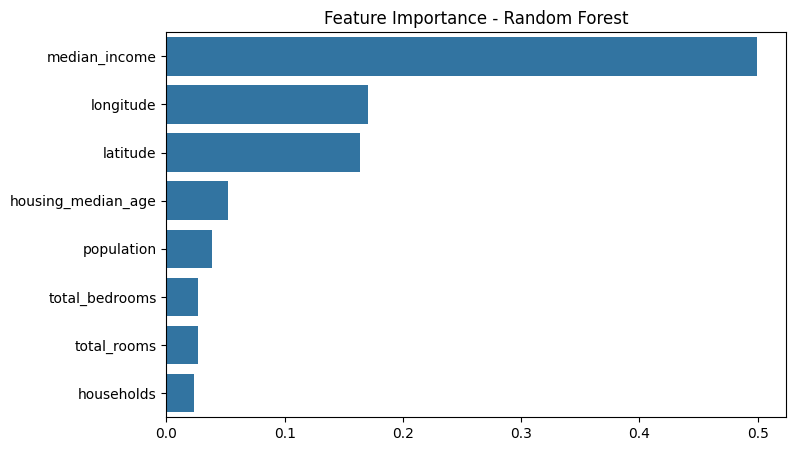

In [15]:
importances = best_rf.feature_importances_
feat_names = training_dataset.columns
feat_names = feat_names[:-1]
feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.ylabel("")
plt.xlabel("")
plt.title("Feature Importance - Random Forest")
plt.show()

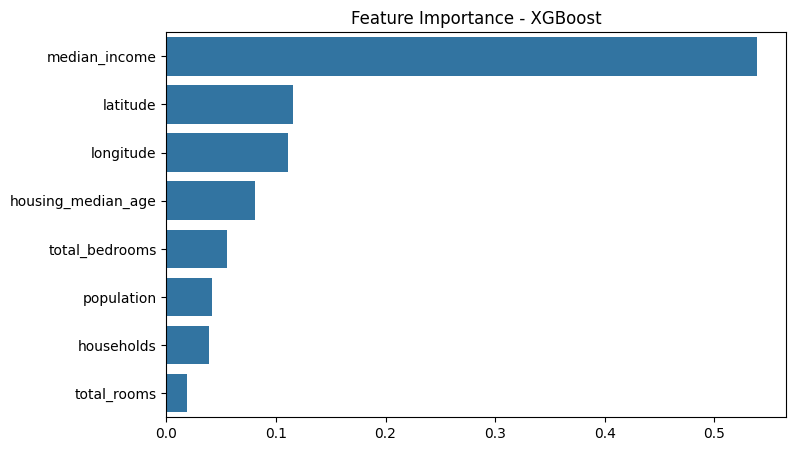

In [16]:
importances = best_xg.feature_importances_
feat_names = training_dataset.columns
feat_names = feat_names[:-1]
feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.ylabel("")
plt.xlabel("")
plt.title("Feature Importance - XGBoost")
plt.show()